In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Projet GE - 4 par  Louis CRISTANTE & Yannis AULLEN CHOUBRAC

### Partie A :

**A1.** 

Dans le cas d'une cavité profonde, on assimile la situation à un petit corps en interaction dans une grande enceinte.

Donc d'après le cours, l'échange radiatif s'exprime comme :

$$\phi_{sw} = - S_s \varepsilon_s \sigma (T_w^4 - T_s^4)$$

Ce résultat peut être obtenu de façon rigoureuse avec l'hypothèse du corps gris :

- La pièce est convexe $\Rightarrow F_{sw} = 1$
- $R_s = \frac{1 - \varepsilon_s}{\varepsilon_s S_s}$ (résistance pièce)
- $R_{sw} = \frac{1}{S_s F_{sw}}$ (résistance géométrique)
- $R_w = \frac{1 - \varepsilon_w}{\varepsilon_w S_w}$ (résistance du four)

$$\Rightarrow \phi_{sw} = \frac{\sigma (T_s^4 - T_w^4)}{R_s + R_{sw} + R_w} = \frac{\sigma (T_s^4 - T_w^4)}{\frac{1 - \varepsilon_s}{\varepsilon_s S_s} + \frac{1}{S_s} + \frac{1 - \varepsilon_w}{\varepsilon_w S_w}} = \frac{\sigma S_s (T_s^4 - T_w^4)}{\frac{1}{\varepsilon_s} + \underbrace{\frac{S_s}{S_w} \frac{1 - \varepsilon_w}{\varepsilon_w}}_{\ll 1 \text{ par hypothèse de cavité profonde}}}$$

On retrouve donc le même résultat.

**A2.**

La thermique de la pièce obéit à  l'équation de la chaleur $\rho c_p \frac{\partial T}{\partial t} = \lambda \nabla^2 T$

Ayant comme conditions aux limites : $-\lambda \frac{\partial T}{\partial n}\Big|_{surface} = \varepsilon_s \sigma (T_w^4 - T_{surface}^4)$

Ce modèle étant trop complexe à résoudre, on va essayer de le simplifier.

Pour ce faire, on va calculer le nombre de Biot :
$$Bi = \frac{h_{rad} l}{\lambda}$$

On a : 

- $l = R = 20 mm$
- $h_{rad} = 80–120 W/m²·K$

Donc : 

$$Bi = 0.14 - 0.21 \Rightarrow Bi > 0,1$$

On ne peut donc pas appliquer l'hypothèse où la conduction interne est très rapide par rapport aux échanges de surface. 

Mais en première approche, le Bi reste proche de 0.1, on va donc calculer la température moyenne comme si elle était uniforme, en sachant bien que la température de surface sera plus élevée.

On utilise donc le modèle simplifié suivant avec un bilan d'énergie:

$$\rho V c_p \frac{dT}{dt} = S_s \varepsilon_s \sigma (T_w^4 - T^4)$$

Ensuite, comme le diamètre est 8 fois plus grand que l'épaisseur, on pourrait négliger les effets de bords de la surface latérale. Et donc se ramener à une équation 1D, avec uniquement une dépendance en z. 

**A3.**

Tout d'abord, on résout donc cette équation :

$$\rho V c_p \frac{dT}{dt} = S_s \varepsilon_s \sigma (T_w^4 - T^4)$$

On intègre par séparation des variables de $t=0, T = T_0$ à $t, T$ :


$$\int_{T_0}^{T} \frac{dT}{T_w^4 - T^4} = \int_{0}^{t} \frac{S_s \varepsilon_s \sigma}{\rho V c_p} dt$$

Comme $T_w^4 - T^4 = (T_w - T)(T_w + T)(T_w^2 + T^2)$, par décomposition en éléments simples :

$$\frac{1}{T_w^4 - T^4} = \frac{A}{T_w - T} + \frac{B}{T_w + T} + \frac{CT + D}{T_w^2 + T^2}$$

Pour trouver ces constantes, on multiplie l'équation par $T_w^4 - T^4$, on évalue en $T=T_w$, puis $T=-T_w$ et enfin $T=0$. On trouve donc : 

$$ A = B = \frac{1}{4T_w^3} \hspace{2cm} D = \frac{1}{2T_w^2}$$

Enfin, à gauche, le coefficient de $T^3$ est $0$. À droite, les termes en $T^3$ sont : $A T^3 - B T^3 - C T^3$. Comme $A=B$, on conclut $C=0$.

On intègre donc $\frac{1}{T_w^4 - T^4} = \frac{1}{4T_w^3} \left[ \frac{1}{T_w - T} + \frac{1}{T_w + T} + \frac{2T_w}{T_w^2 + T^2} \right]$, ce qui donne :

$$t(T) = \frac{\rho V c_p}{4 S_s \varepsilon_s \sigma T_w^3} \left[ 2 \arctan\left(\frac{T}{T_w}\right) + \ln\left(\frac{T_w + T}{T_w - T}\right) \right]_{T_0}^{T}$$

On ne peut pas inverser mathématiquement cette expression, on va donc procéder à une résolution numérique.

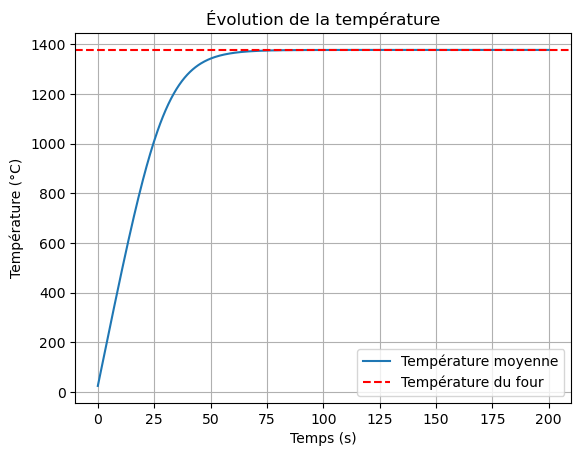

In [ ]:
# Param
rho = 8190           # kg/m3 
cp = 435             # J/kg.K
R = 0.02             # m
e = 0.005            # m
eps_s = 0.75         
sigma = 5.67e-8      # W/m².K⁴
Tw = 1650            # K 
T0 = 25 + 273.15     # K 

V = (np.pi * R**2) * e
S_s = 2 * (np.pi * R**2) + (np.pi * 2 * R * e)

def f(T, t):
    return (S_s * eps_s * sigma / (rho * V * cp)) * (Tw**4 - T**4)

# Résolution 
temps = np.linspace(0, 200, 500) 
T_t = odeint(f, T0, temps) 

# Graphique
plt.plot(temps, T_t - 273.15, label="Température moyenne")
plt.axhline(Tw - 273.15, color='r', linestyle='--', label="Température du four")
plt.xlabel("Temps (s)")
plt.ylabel("Température (°C)")
plt.title("Évolution de la température")
plt.legend()
plt.grid()
plt.show()

Mais, maintenant on est bloqué pour calculer la température de surface. On va donc procéder au calcul en 1D. Notons que pour que cette méthode soit stable, il faut que le nombre de Fourier $Fo= \frac{\lambda \cdot \Delta t}{\rho \cdot c_p \Delta z^2}$ soit inférieur à $0.5$

A t = 10 s :
  T_surface = 671.1 K (398.0 °C)
  T_moyenne = 649.9 K (376.8 °C)
  Énergie fournie = 7.87 kJ
A t = 60 s :
  T_surface = 1604.1 K (1330.9 °C)
  T_moyenne = 1601.7 K (1328.6 °C)
  Énergie fournie = 29.18 kJ
A t = 180 s :
  T_surface = 1650.0 K (1376.8 °C)
  T_moyenne = 1650.0 K (1376.8 °C)
  Énergie fournie = 30.26 kJ


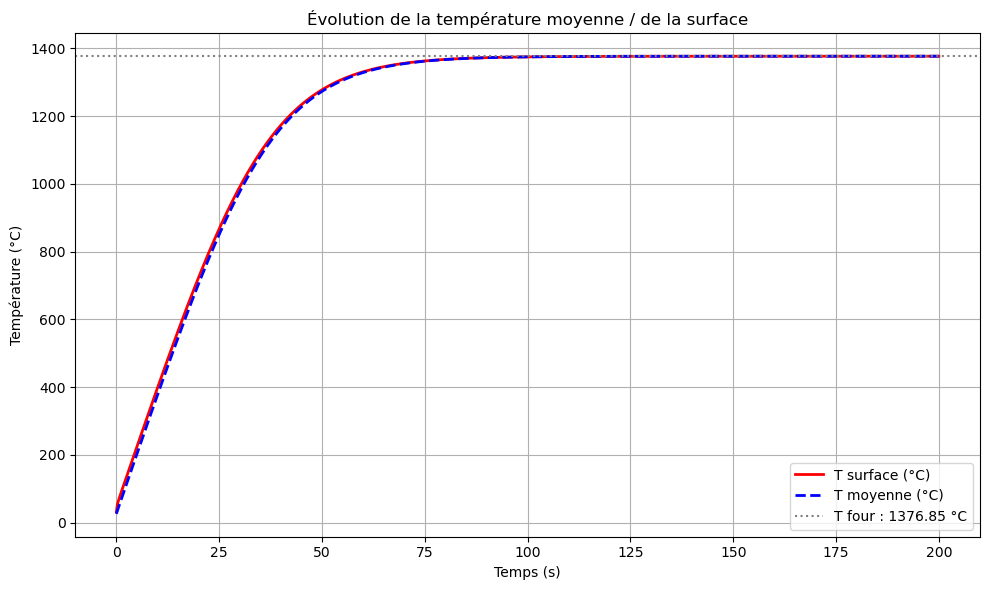

In [ ]:
# Param
rho = 8190         # kg/m³
cp = 435           # J/kg.K
lambd = 11.4       # W/m.K
eps = 0.75         
sigma = 5.67e-8    # W/m².K⁴
Tw = 1650          # K
T0 = 25 + 273.15   # K
R = 0.02           # m
e = 0.005          # m

V = (np.pi * R**2) * e 

# Discrétisation spatiale et temporelle
Nz = 19            # Nombre de noeuds spatiaux
dz = e / (Nz - 1)  # Pas spatial
dt = 0.01         # Pas de temps (s)

# Respect condition stabilité
Fo = lambd * dt / (dz**2 * (rho * cp))
if Fo >= 0.5:
    print(f"Instabilité numérique : Fo = {Fo:.3f}")

t_fin = 200        
Nt = int(t_fin / dt) + 1
time = np.linspace(0, t_fin, Nt)

# Initialisation
T = np.ones(Nz) * T0
T_new = np.copy(T)

T_surface = []
T_moyenne = []
results = {}
points_mesures = [10, 60, 180]

# Résolution
for t in time:
    # Flux aux frontières (z=0 et z=e), axe z orienté de la surface vers l'intérieur
    phi_rad_0 = eps * sigma * (Tw**4 - T[0]**4)
    phi_rad_e = eps * sigma * (Tw**4 - T[-1]**4)

    # Maj des noeuds de surface 
    T_new[0] = T[0] + (2 * dt / (rho * cp * dz)) * (phi_rad_0 - lambd * (T[0] - T[1]) / dz)
    T_new[-1] = T[-1] + (2 * dt / (rho * cp * dz)) * (phi_rad_e - lambd * (T[-1] - T[-2]) / dz)
    
    # Maj des noeuds internes
    for j in range(1, Nz - 1):
        T_new[j] = T[j] + Fo * (T[j+1] - 2*T[j] + T[j-1])
        
    T = np.copy(T_new)
    T_moy = np.mean(T)
    
    # Calcul températures de surface et moyenne
    T_surface.append(T[0])
    T_moyenne.append(T_moy)
    
    # Extraction des valeurs aux temps demandés
    for t_mes in points_mesures:
        if abs(t - t_mes) < dt / 2:
            energie = rho * V * cp * (T_moy - T0)
            results[t_mes] = {'Ts': T[0], 'Tm': T_moy, 'E': energie}

# Points de mesure
for t_mes in points_mesures:
    res = results[t_mes]
    print(f"A t = {t_mes} s :")
    print(f"  T_surface = {res['Ts']:.1f} K ({res['Ts']-273.15:.1f} °C)")
    print(f"  T_moyenne = {res['Tm']:.1f} K ({res['Tm']-273.15:.1f} °C)")
    print(f"  Énergie fournie = {res['E']/1000:.2f} kJ")

# Graphique
plt.figure(figsize=(10, 6))
plt.plot(time, [T - 273.15 for T in T_surface], label="T surface (°C)", color="red", linewidth=2)
plt.plot(time, [T - 273.15 for T in T_moyenne], label="T moyenne (°C)", color="blue", linestyle="--", linewidth=2)
plt.axhline(Tw - 273.15, color='gray', linestyle=':', label="T four : 1376.85 °C")
plt.title("Évolution de la température moyenne / de la surface")
plt.xlabel("Temps (s)")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

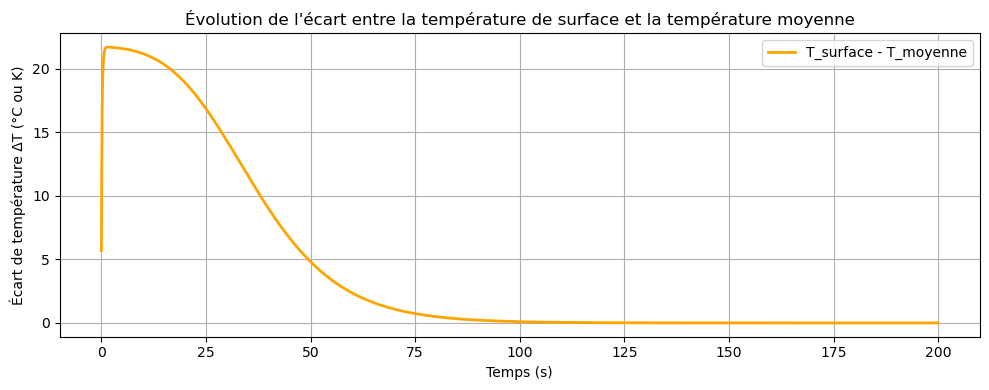

In [ ]:
# Calcul de l'écart 
delta_T = np.array(T_surface) - np.array(T_moyenne)

plt.figure(figsize=(10, 4))
plt.plot(time, delta_T, color="orange", linewidth=2, label="T_surface - T_moyenne")
plt.title("Évolution de l'écart entre la température de surface et la température moyenne")
plt.xlabel("Temps (s)")
plt.ylabel("Écart de température (°C ou K)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Partie B :

**B1.**

On sait que :  $U \approx 12$ m/s et $T_\infty = 30$ °C

Pour ce dimensionnement, on nous donne la corrélation de Martin:
$$Nu_0=0.42Re^{0.5}Pr^{0.42}\left(\frac{H}{D}\right)^{-0.23}$$

où $H$ est la distance buse-pièce, $D$ le diamètre de la buse.

Comme $Nu_0=\frac{h \cdot D}{\lambda_{air}}$, $Re=\frac{U \cdot D \cdot \rho_{air}}{\mu_{air}}$ et $Pr = \frac{\mu_{air} \cdot c_p}{\lambda_{air}}$ on obtient donc:

$$h = 0.42 \cdot \frac{\lambda_{air}}{D} \cdot \left( \frac{U \cdot D \cdot \rho_{air}}{\mu_{air}} \right)^{0.5} \cdot \left( \frac{\mu_{air} \cdot c_p}{\lambda_{air}} \right)^{0.42} \cdot \left(\frac{H}{D}\right)^{-0.23}$$

L'équation fait apparaître deux inconnues géométriques $D$ et $H$. Pour résoudre ce problème de dimensionnement, nous allons :
1. Fixer un ratio d'espacement $\frac{H}{D}$ (les valeurs optimales pour des jets impactants se situent généralement entre 4 et 8).
2. Calculer le diamètre $D$ nécessaire pour atteindre les bornes de notre $h$ cible (80 et 120 W/m²·K).
3. En déduire la hauteur $H$ correspondante.